In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# -----------------------------
# 1. Chargement et nettoyage des données
# -----------------------------
df = pd.read_csv('/content/Training_BOP.csv')

# Remplacer -99 par NaN
df = df.replace(-99, np.nan)

# Remplir les valeurs manquantes
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# -----------------------------
# 2. Encodage des colonnes catégorielles
# -----------------------------
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = df[col].astype(str)  # convertir en string pour uniformité
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# -----------------------------
# 3. Séparer features / target
# -----------------------------
X = df.drop(columns=['went_on_backorder', 'sku'])
y = df['went_on_backorder']

# -----------------------------
# 4. Standardisation des colonnes numériques
# -----------------------------
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[num_cols] = scaler.fit_transform(X[num_cols])

# -----------------------------
# 5. Scénario 1 : GAN + stratifié
# -----------------------------
# Exemple simplifié : on suppose que df_gan contient le dataset GAN final
df_gan = df.copy()  # remplacer par GAN généré

X1 = df_gan.drop(columns=['went_on_backorder', 'sku'])
y1 = df_gan['went_on_backorder']

num_cols1 = X1.select_dtypes(include=['int64', 'float64']).columns
X1_scaled = X1.copy()
X1_scaled[num_cols1] = scaler.fit_transform(X1[num_cols1])

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X1_scaled, y1, test_size=0.2, stratify=y1, random_state=42)

# -----------------------------
# 6. Scénario 2 : SMOTE + stratifié
# -----------------------------
smote = SMOTE(random_state=42)
X_bal, y_bal = smote.fit_resample(X, y)

num_cols2 = X_bal.select_dtypes(include=['int64', 'float64']).columns
X_bal_scaled = X_bal.copy()
X_bal_scaled[num_cols2] = scaler.fit_transform(X_bal[num_cols2])

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_bal_scaled, y_bal, test_size=0.2, stratify=y_bal, random_state=42)

# -----------------------------
# 7. Scénario 3 : Downsampling 50% + stratifié
# -----------------------------
minority_df = df[df['went_on_backorder'] == 1]
majority_df = df[df['went_on_backorder'] == 0]
majority_downsampled = majority_df.sample(frac=0.5, random_state=42)

df_down = pd.concat([minority_df, majority_downsampled], axis=0)

X3 = df_down.drop('went_on_backorder', axis=1)
y3 = df_down['went_on_backorder']

num_cols3 = X3.select_dtypes(include=['int64', 'float64']).columns
X3_scaled = X3.copy()
X3_scaled[num_cols3] = scaler.fit_transform(X3[num_cols3])

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X3_scaled, y3, test_size=0.2, stratify=y3, random_state=42)

# -----------------------------
# ✅ Les trois scénarios sont prêts pour :
# Random Forest, SVM et AdaBoost
# -----------------------------


/tmp/ipython-input-1772675571.py:10: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/Training_BOP.csv')
/tmp/ipython-input-1772675571.py:18: UserWarning: Unable to sort modes: '<' not supported between instances of 'str' and 'int'
  df[col] = df[col].fillna(df[col].mode()[0])


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model_metrics(model, X_train, X_test, y_train, y_test, model_name, scenario_name):
    # Entraînement
    model.fit(X_train, y_train)

    # Prédictions
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:,1]
    else:  # SVM
        y_proba = model.decision_function(X_test)
        y_proba = (y_proba - y_proba.min()) / (y_proba.max() - y_proba.min())

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    print(f"{model_name} - {scenario_name} Metrics:")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")

    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} - {scenario_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Courbe ROC
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} - {scenario_name} - ROC Curve")
    plt.legend()
    plt.grid(True)
    plt.show()



Random Forest - GAN + Stratified
Random Forest - GAN + Stratified Metrics:
Accuracy : 0.9949
Precision: 0.8785
Recall   : 0.2753
F1-score : 0.4193
ROC-AUC  : 0.9698


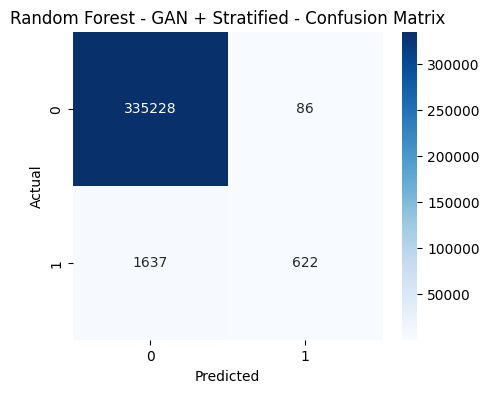

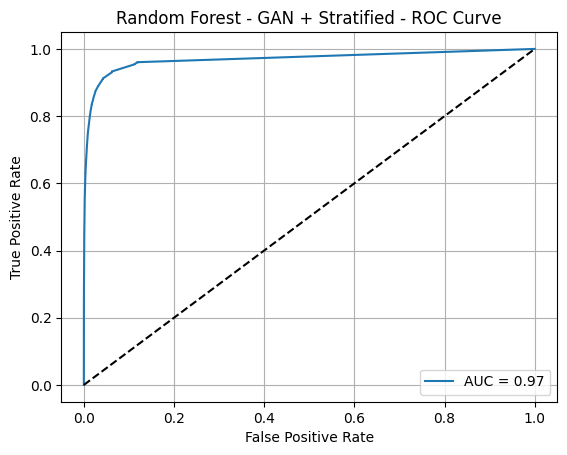


Logistic Regression - GAN + Stratified
Logistic Regression - GAN + Stratified Metrics:
Accuracy : 0.9933
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000
ROC-AUC  : 0.6411


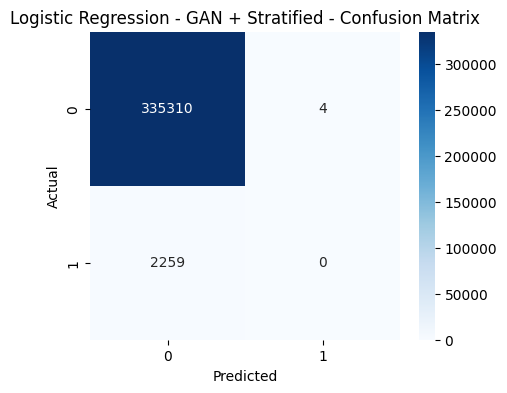

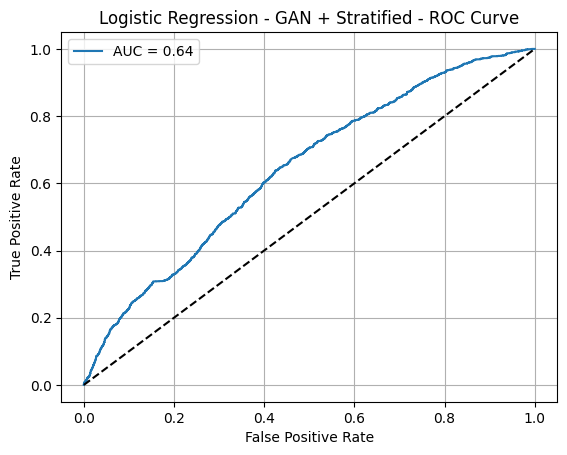


AdaBoost - GAN + Stratified
AdaBoost - GAN + Stratified Metrics:
Accuracy : 0.9931
Precision: 0.3041
Recall   : 0.0261
F1-score : 0.0481
ROC-AUC  : 0.9297


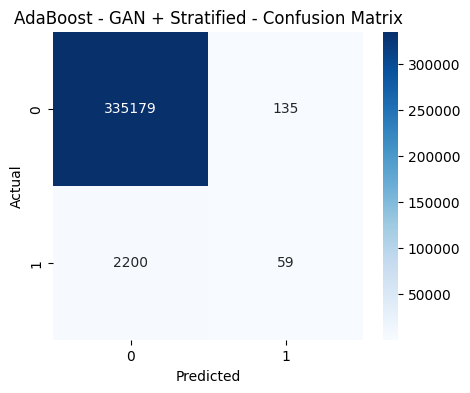

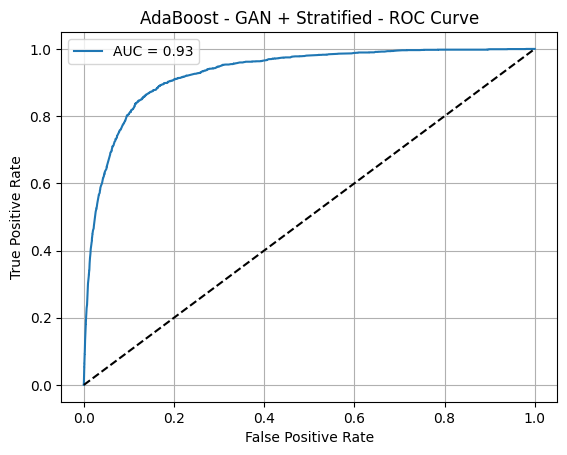


Random Forest - SMOTE + Stratified
Random Forest - SMOTE + Stratified Metrics:
Accuracy : 0.9952
Precision: 0.9961
Recall   : 0.9943
F1-score : 0.9952
ROC-AUC  : 0.9998


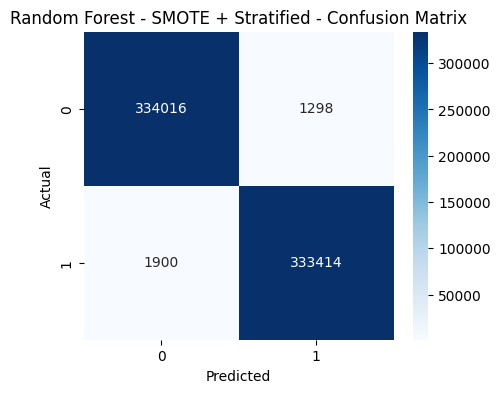

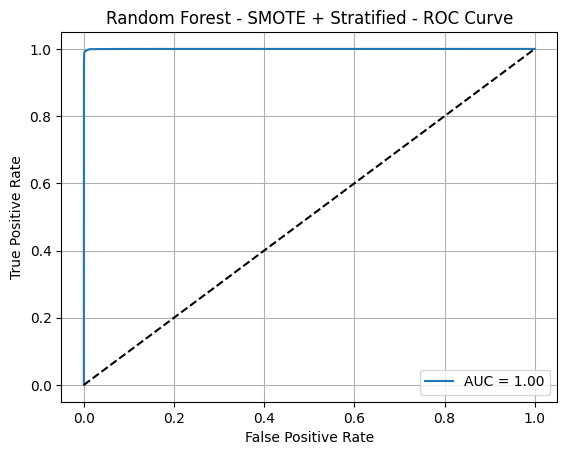


Logistic Regression - SMOTE + Stratified
Logistic Regression - SMOTE + Stratified Metrics:
Accuracy : 0.7029
Precision: 0.6868
Recall   : 0.7460
F1-score : 0.7152
ROC-AUC  : 0.7749


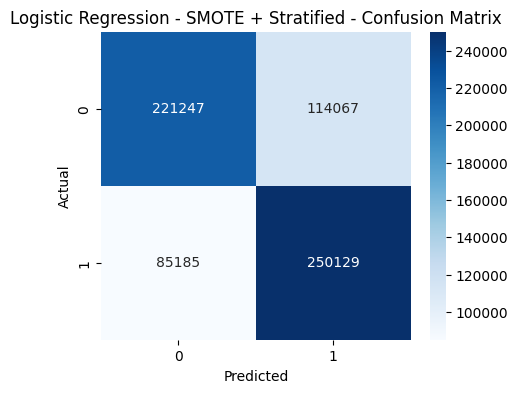

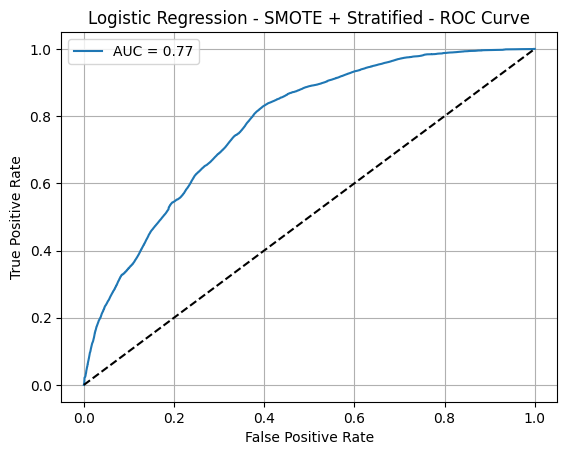


AdaBoost - SMOTE + Stratified
AdaBoost - SMOTE + Stratified Metrics:
Accuracy : 0.8805
Precision: 0.8751
Recall   : 0.8878
F1-score : 0.8814
ROC-AUC  : 0.9459


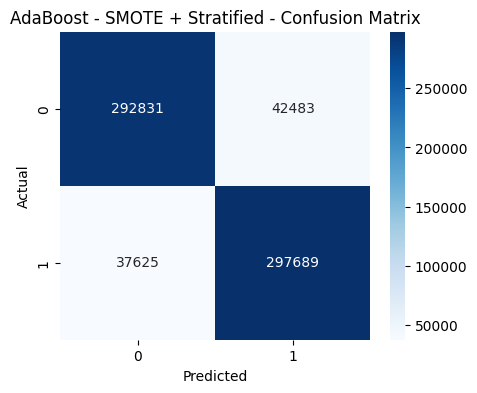

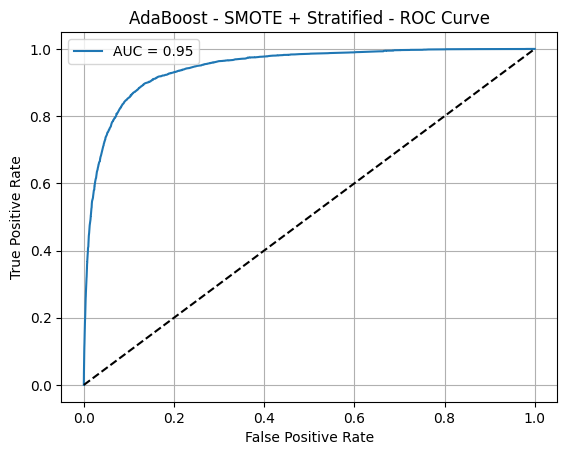


Random Forest - Downsampling 50% + Stratified
Random Forest - Downsampling 50% + Stratified Metrics:
Accuracy : 0.9899
Precision: 0.8135
Recall   : 0.3090
F1-score : 0.4479
ROC-AUC  : 0.9674


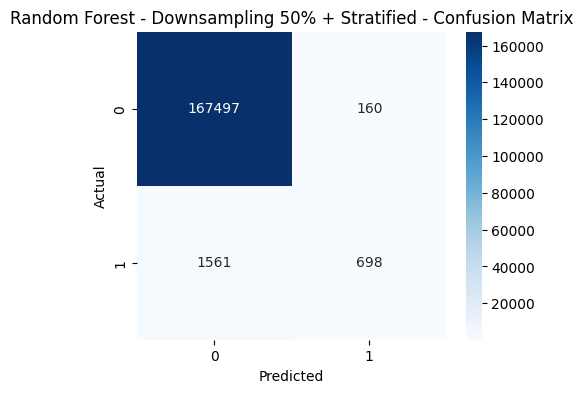

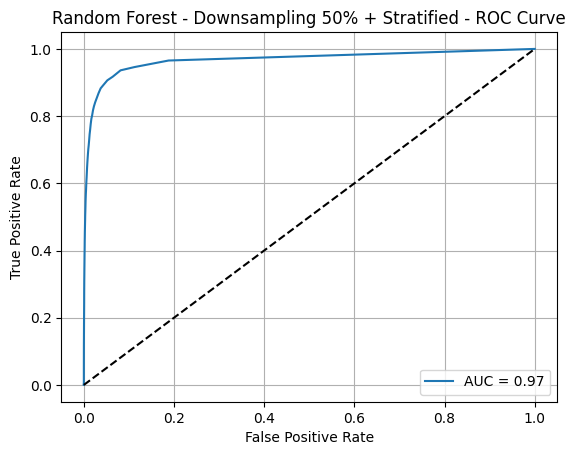


Logistic Regression - Downsampling 50% + Stratified
Logistic Regression - Downsampling 50% + Stratified Metrics:
Accuracy : 0.9867
Precision: 0.2000
Recall   : 0.0004
F1-score : 0.0009
ROC-AUC  : 0.7126


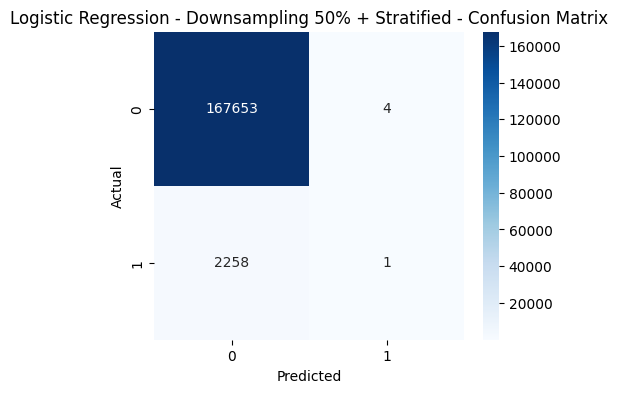

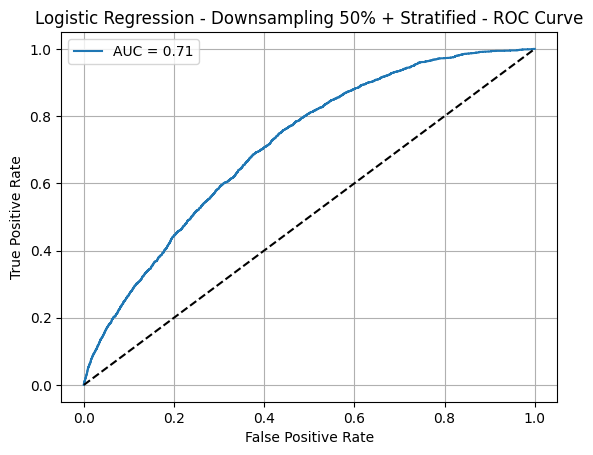


AdaBoost - Downsampling 50% + Stratified
AdaBoost - Downsampling 50% + Stratified Metrics:
Accuracy : 0.9866
Precision: 0.4803
Recall   : 0.0969
F1-score : 0.1613
ROC-AUC  : 0.9376


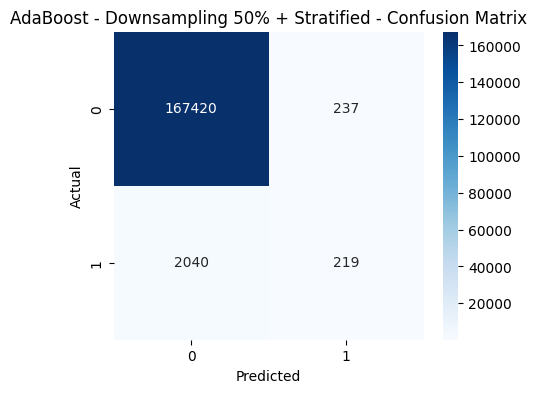

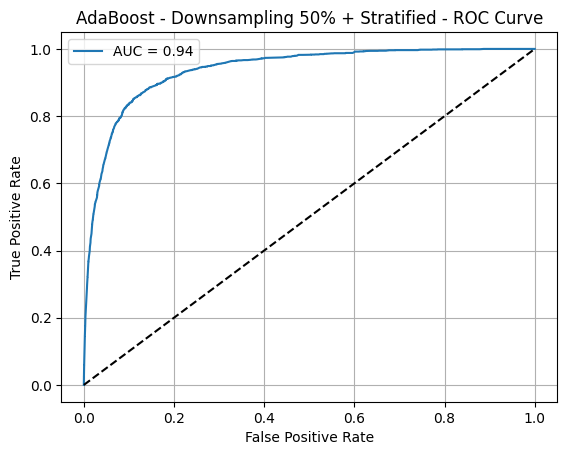

In [ ]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression

models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42)
}

scenarios = {
    "GAN + Stratified": (X_train1, X_test1, y_train1, y_test1),
    "SMOTE + Stratified": (X_train2, X_test2, y_train2, y_test2),
    "Downsampling 50% + Stratified": (X_train3, X_test3, y_train3, y_test3)
}

for scenario_name, (X_tr, X_te, y_tr, y_te) in scenarios.items():
    for model_name, model in models.items():
        print(f"\n====================\n{model_name} - {scenario_name}\n====================")
        evaluate_model_metrics(model, X_tr, X_te, y_tr, y_te, model_name, scenario_name)
